In [1]:
from PIL import Image
from matplotlib import pyplot as plt
import numpy as np

import torch
from torchvision.transforms.functional import to_tensor

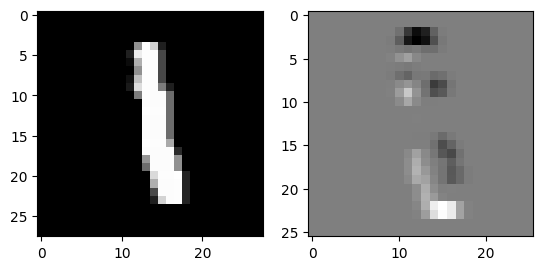

In [2]:

image = Image.open(".\data\img.png")
image_tensor = to_tensor(image) # тензор [1, 28, 28]
image_tensor = image_tensor.unsqueeze(0)

kernel = torch.Tensor([[[[3, 10, 3], 
                         [0, 0, 0], 
                         [-3, -10, -3]]]])

result = torch.nn.functional.conv2d(image_tensor, kernel)

# визуализация
fig = plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(image, cmap = 'gray')

plt.subplot(1, 2, 2)
plt.imshow(result[0][0], cmap = 'gray')

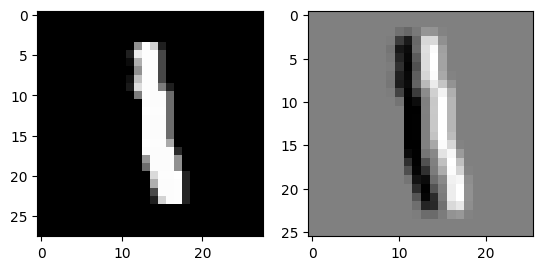

In [3]:
kernel = torch.Tensor([[[[3, 0, -3], 
                         [10, 0, -10], 
                         [3, 0, -3]]]])

result = torch.nn.functional.conv2d(image_tensor, kernel)

# визуализация
fig = plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(image, cmap = 'gray')

plt.subplot(1, 2, 2)
plt.imshow(result[0][0], cmap = 'gray')

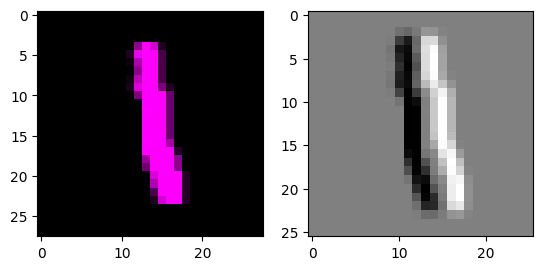

In [4]:
image = Image.open(".\data\img_colored.png")
image_tensor = to_tensor(image) # тензор [1, 3, 28, 28]
image_tensor = image_tensor.unsqueeze(0) 

kernel = np.array([[3, 0, -3], # обычный фильтр вертикальных линий
                   [10, 0, -10],
                   [3, 0, -3]])

kernel_3D = np.tile(kernel, (3, 1, 1)) # трехмерный фильтр вертикальных линий
kernel_3D = torch.Tensor(kernel_3D) 
kernel_3D = kernel_3D.unsqueeze(0) # приведен к форме [1, 3, 3, 3]

result = torch.nn.functional.conv2d(image_tensor, kernel_3D)

# визуализация
fig = plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(image)

plt.subplot(1, 2, 2)
plt.imshow(result[0][0], cmap = 'gray')

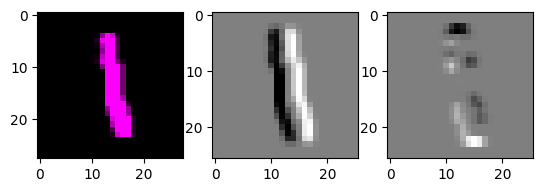

In [5]:
image = Image.open(".\data\img_colored.png")
image_tensor = to_tensor(image) # тензор [1, 3, 28, 28]
# добавлено еще одно измерение, чтобы получить [1, 3, 28, 28]
image_tensor = image_tensor.unsqueeze(0)

kernel_v = np.array([[3, 0, -3], # обычный фильтр вертикальных линий
                     [10, 0, -10],
                     [3, 0, -3]])

kernel_h = np.array([[3, 10, 3], # обычный фильтр горизонтальных линий
                     [0, 0, 0],
                     [-3, -10, -3]])

kernel_v_3D = np.tile(kernel_v, (3, 1, 1)) # трехмерный фильтр вертикальных линий

kernel_h_3D = np.tile(kernel_h, (3, 1, 1)) # трехмерный фильтр горизонтальных линий

kernels = torch.Tensor(np.stack([kernel_v_3D, kernel_h_3D])) # тензор с фильтрами

result = torch.nn.functional.conv2d(image_tensor, kernels)

# визуализация
fig = plt.figure()
plt.subplot(1, 3, 1)
plt.imshow(image)

plt.subplot(1, 3, 2)
plt.imshow(result[0][0], cmap='gray') # карта признака вертикальных линий

plt.subplot(1, 3, 3)
plt.imshow(result[0][1], cmap='gray') # карта признака горизонтальных линий

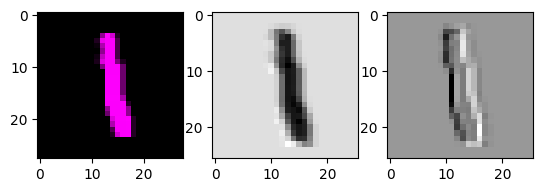

In [6]:
image = Image.open(".\data\img_colored.png")
image_tensor = to_tensor(image)
image_tensor = image_tensor.unsqueeze(0)

# Создание слоя для обработки 3-канального изображения
# 2-мя фильтрами
# размером 3х3 (при квадратном фильтре указывается только одна сторона)
conv_layer = torch.nn.Conv2d(3, 2, 3)     # заметим, что мы не указываем сами матрицы фильтров

# Слой в pytorch - это функция
# Применение функции к входному изображению
# .detach() позволяет осуществить операцию
# и получить конкретные значения из pytorch тензора.
result = conv_layer(image_tensor).detach()

# визуализация
fig = plt.figure()
plt.subplot(1, 3, 1)
plt.imshow(image)

plt.subplot(1, 3, 2)
plt.imshow(result[0][0], cmap='gray') # карта признака 1

plt.subplot(1, 3, 3)
plt.imshow(result[0][1], cmap='gray') # карта признака 2

Однако в коде нигде не были заданы значения фильтров, поэтому и в результате получились не карты признаков горизонтальных и вертикальных линий, а… какие-то карты. Если посмотреть `conv_layer.weight` , то есть веса нейронов — значения фильтров свертки, то выяснится, что они состоят из случайных околонулевых значений. Поэтому и результаты — это какие-то случайные карты.
Чтобы веса нейронов стали корректными, нужно обучить этот слой как часть нейронной сети

In [7]:
conv_layer.weight

Parameter containing:
tensor([[[[-0.1651, -0.1758,  0.0392],
          [-0.1799, -0.1417, -0.1427],
          [-0.0812,  0.1624,  0.0853]],

         [[ 0.1172, -0.0655,  0.0704],
          [ 0.0549,  0.0410, -0.0650],
          [-0.0248, -0.0771, -0.0608]],

         [[-0.1404,  0.0904,  0.1309],
          [ 0.1653, -0.1495, -0.0502],
          [ 0.0451, -0.1900, -0.1152]]],


        [[[ 0.0495,  0.1007, -0.1704],
          [-0.0921,  0.1434, -0.1495],
          [-0.1398,  0.1114, -0.1635]],

         [[ 0.1410,  0.0914,  0.0119],
          [-0.0923, -0.0434, -0.0288],
          [ 0.1471, -0.0748, -0.1662]],

         [[-0.1577,  0.1559,  0.1179],
          [ 0.1377, -0.0526, -0.1491],
          [ 0.0871,  0.0168,  0.0746]]]], requires_grad=True)

In [8]:
image = Image.open("./data/img_colored.png")
image_tensor = to_tensor(image)
image_tensor = image_tensor.unsqueeze(0)

conv_layer = torch.nn.Conv2d(3, 20, 3)
result = conv_layer(image_tensor).detach()

print("Размерность тензора: ", result.shape)

Размерность тензора:  torch.Size([1, 20, 26, 26])


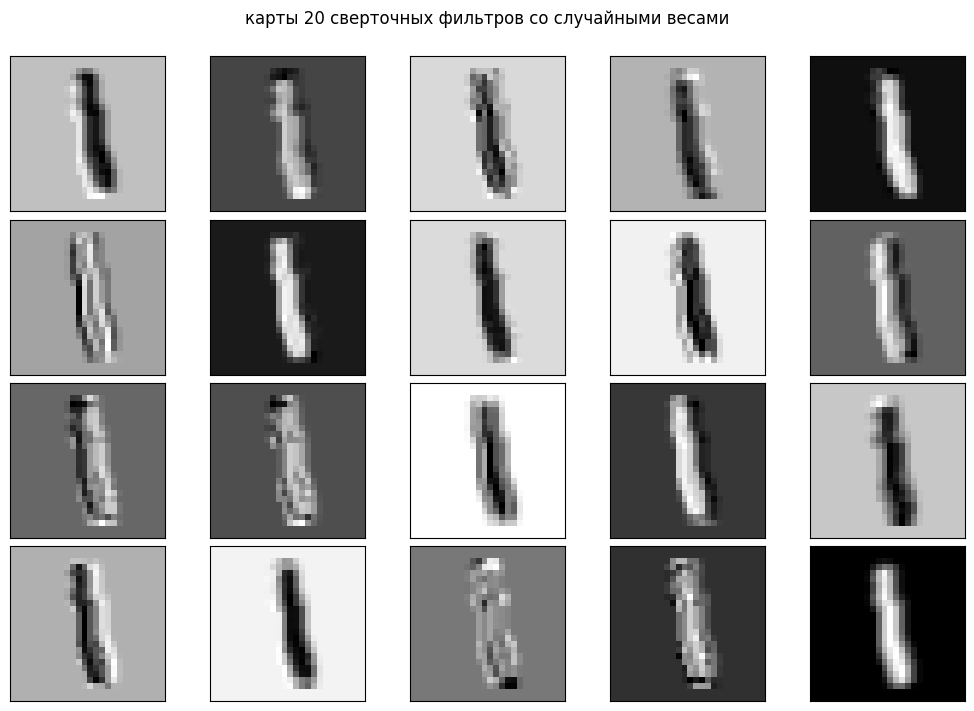

In [16]:
fig, axes = plt.subplots(4, 5, figsize=(10,7), layout='constrained')
axes = axes.flatten()

for i in range(len(axes)):
    axes[i].imshow(result[0][i], cmap='gray') 
    axes[i].set_xticks([])
    axes[i].set_yticks([])

fig.suptitle('карты 20 сверточных фильтров со случайными весами\n')
plt.show()

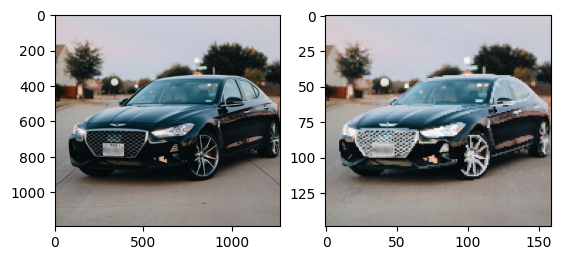

In [17]:
image = Image.open("./data/car.png")
image_tensor = to_tensor(image)
image_tensor = image_tensor.unsqueeze(0)

pool_layer = torch.nn.MaxPool2d(8, stride=8)

result = pool_layer(image_tensor).detach()

# визуализация
fig = plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(image)

plt.subplot(1, 2, 2)
plt.imshow(result[0].permute(1, 2, 0))